In [11]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy
from matplotlib import cm
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [12]:
tmaxUTC = xr.open_dataset("/Projects/era5/Dailies/monolevel/tmax.2m.1941.nc")
tmaxUTC['lon'] = (tmaxUTC['lon'] + 180) % 360 - 180                                                                                                           
tmaxUTC = tmaxUTC.sortby(tmaxUTC.lon)
tmaxSLD = xr.open_dataset("/Projects/RAPrototype/ERA5/UTCTime/tmax.2m.1941.UTC.nc")
tmaxSLD['lon'] = (tmaxSLD['lon'] + 180) % 360 - 180                                                                                                           
tmaxSLD = tmaxSLD.sortby(tmaxSLD.lon)
tmaxSLD['time'] = tmaxUTC['time']

In [13]:
tmaxUTC = tmaxUTC.load()
tmaxSLD = tmaxSLD.load()

In [14]:
tmaxUTC['time'][182].dt.strftime('%Y-%m-%d').values

array('1941-07-02', dtype=object)

In [15]:
FairbanksUTC = tmaxUTC['tmax'].sel(lat=64.8, lon=-147.8, method='nearest')
DenverUTC = tmaxUTC['tmax'].sel(lat=39.7, lon=-105.0, method='nearest')
SanFranciscoUTC = tmaxUTC['tmax'].sel(lat=37.8, lon=-122.4, method='nearest')
ChicagoUTC = tmaxUTC['tmax'].sel(lat=41.8, lon=-87.6, method='nearest')
NYCUTC = tmaxUTC['tmax'].sel(lat=40.7, lon=-74.0, method='nearest')


FairbanksSLD = tmaxSLD['tmax'].sel(lat=64.8, lon=-147.8, method='nearest')
DenverSLD = tmaxSLD['tmax'].sel(lat=39.7, lon=-105.0, method='nearest')
SanFranciscoSLD = tmaxSLD['tmax'].sel(lat=37.8, lon=-122.4, method='nearest')
ChicagoSLD = tmaxSLD['tmax'].sel(lat=41.8, lon=-87.6, method='nearest')
NYCSLD = tmaxSLD['tmax'].sel(lat=40.7, lon=-74.0, method='nearest')

In [16]:
UTC = [FairbanksUTC, DenverUTC, SanFranciscoUTC, ChicagoUTC, NYCUTC]
SLD = [FairbanksSLD, DenverSLD, SanFranciscoSLD, ChicagoSLD, NYCSLD]
tip = ['Fairbanks', 'Denver', 'SanFrancisco', 'Chicago', 'NYC' ]

/tmp/ipykernel_2805995/1329674429.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


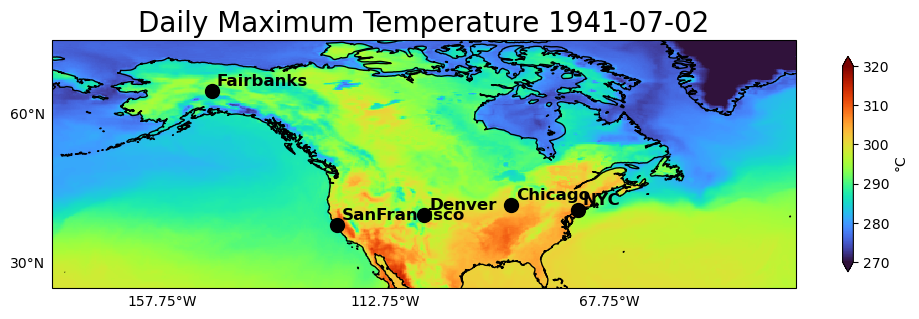

In [17]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(12,8),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=182).plot.pcolormesh(ax=ax,cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.35},vmin=270,vmax=320) 
for i in range(len(tip)):
    ax.plot(UTC[i]['lon'], UTC[i]['lat'], marker='o', color='black', markersize=10, transform=proj)
    ax.text(UTC[i]['lon']+1, UTC[i]['lat']+1, tip[i], fontsize=12, fontweight='bold', color='black', transform=proj)
gl1 = ax.gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax.add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax.set_extent([-180, -30, 25, 75], crs=ccrs.PlateCarree())
ax.set_title('UTC',fontsize=20)
custom_xticks = [0-180, 22.25-180, 67.25-180,112.25-180,157.25-180, 180-180, 202.25-180,247.25-180,292.25-180,337.25-180,360-180]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner

gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.title(f"Daily Maximum Temperature {tmaxUTC['time'][182].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

In [18]:
CB_color = ['#377eb8', '#ff7f00', '#4daf4a',\
            '#e41a1c', '#a65628', '#984ea3',\
            '#999999', '#f781bf', '#dede00']

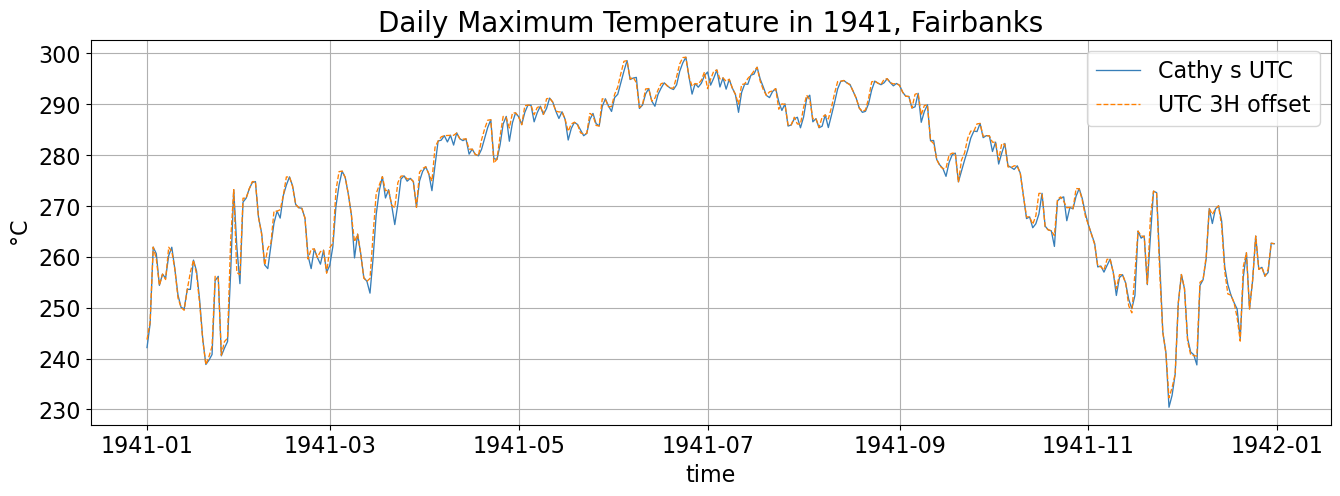

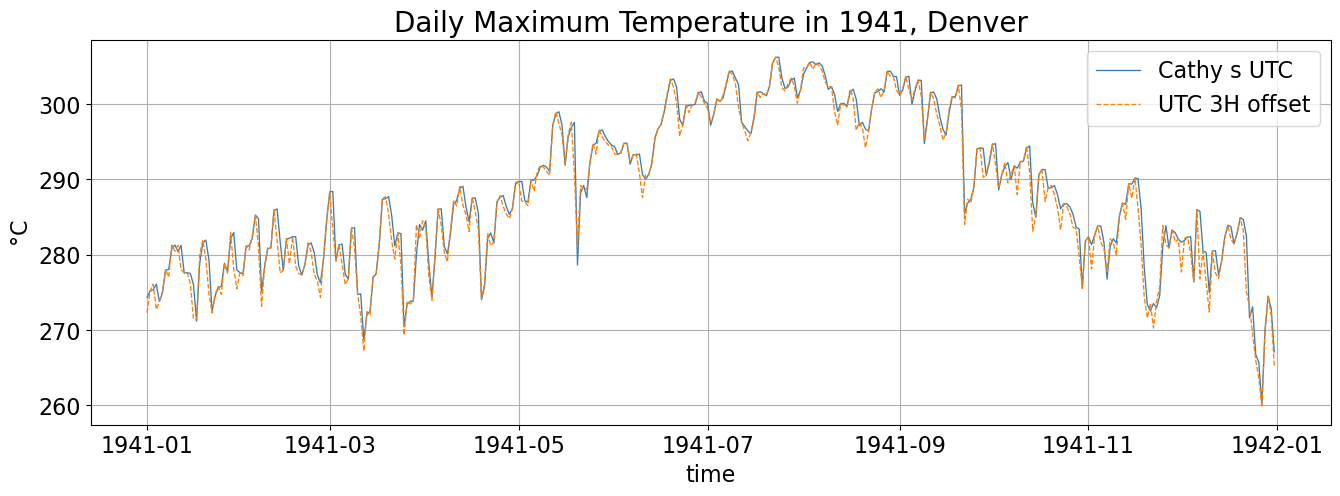

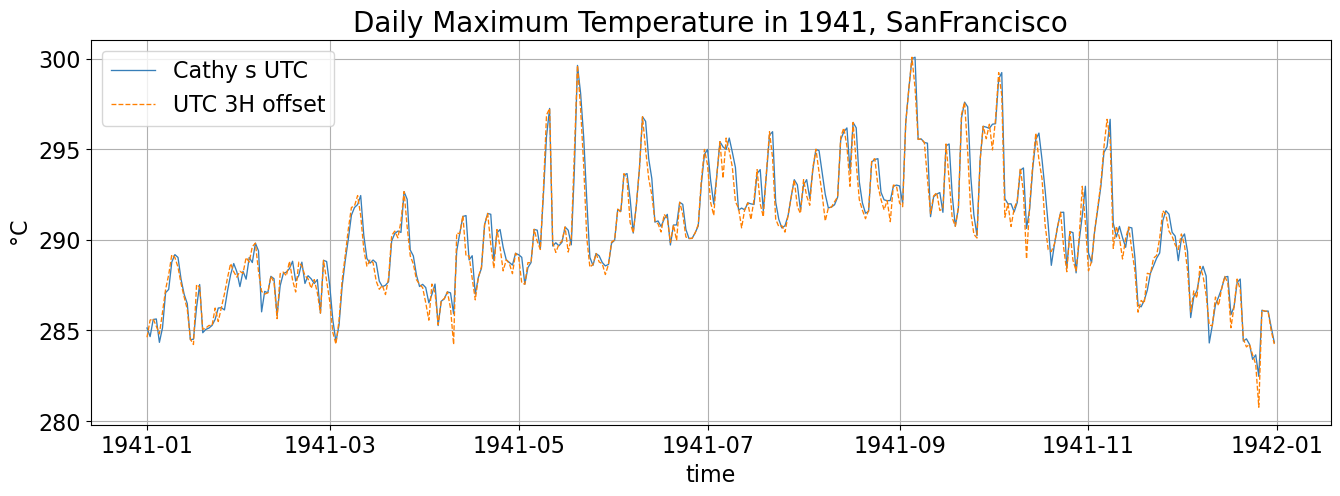

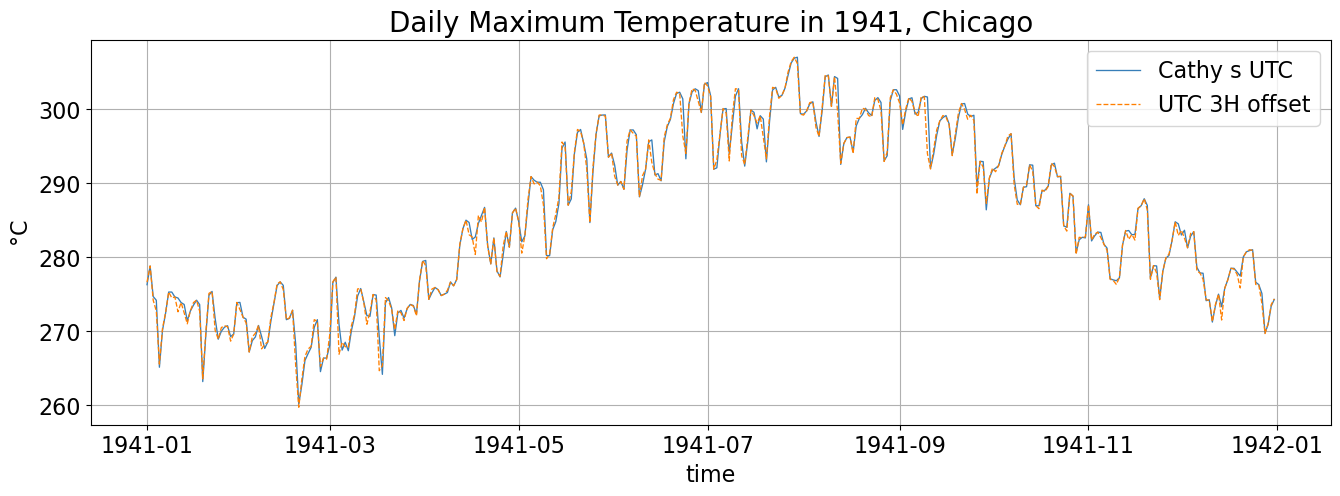

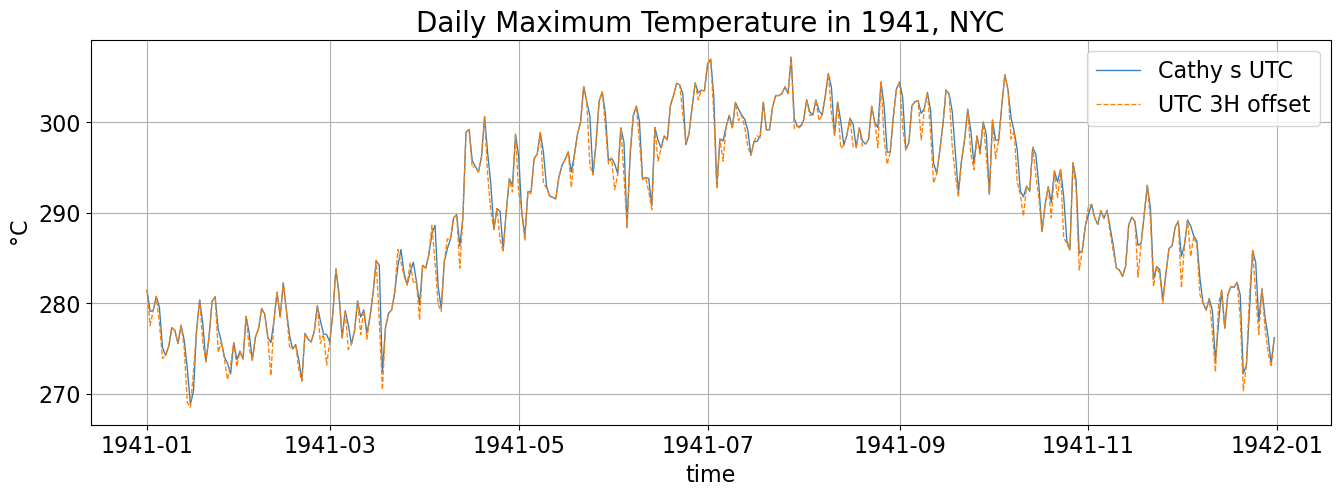

In [19]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'],UTC[ip],color=CB_color[0],linewidth=0.95,label='Cathy s UTC')
  ax.plot(tmaxSLD['time'],SLD[ip],color=CB_color[1],linewidth=0.95,linestyle='--',label='UTC 3H offset')
  ax.tick_params(labelsize=16)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Daily Maximum Temperature in {tmaxUTC["time"].dt.strftime("%Y")[0].data}, {tip[ip]}',fontsize=20)
  plt.show()

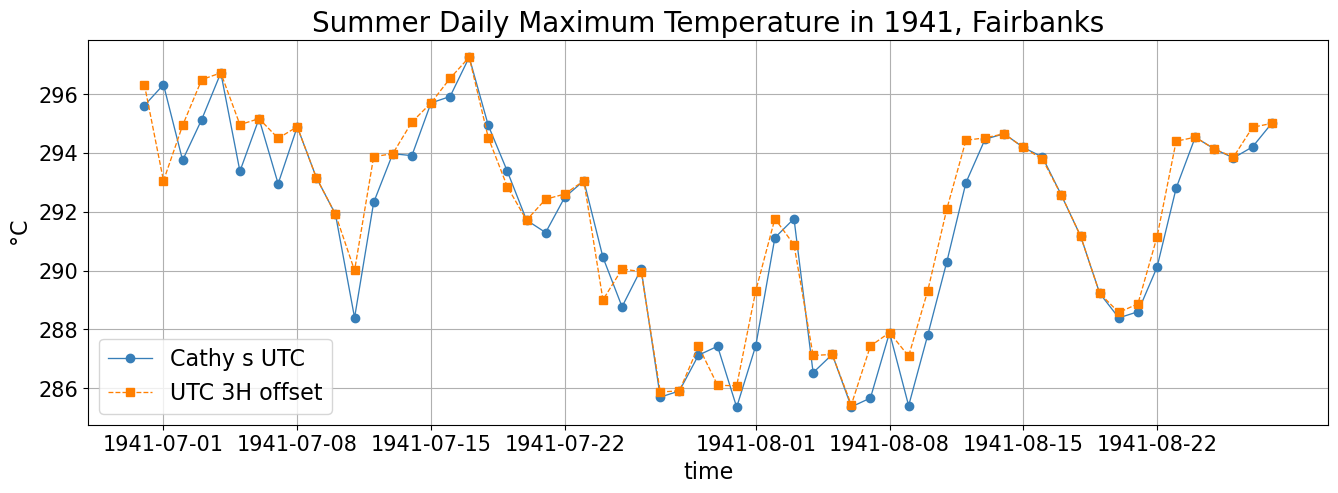

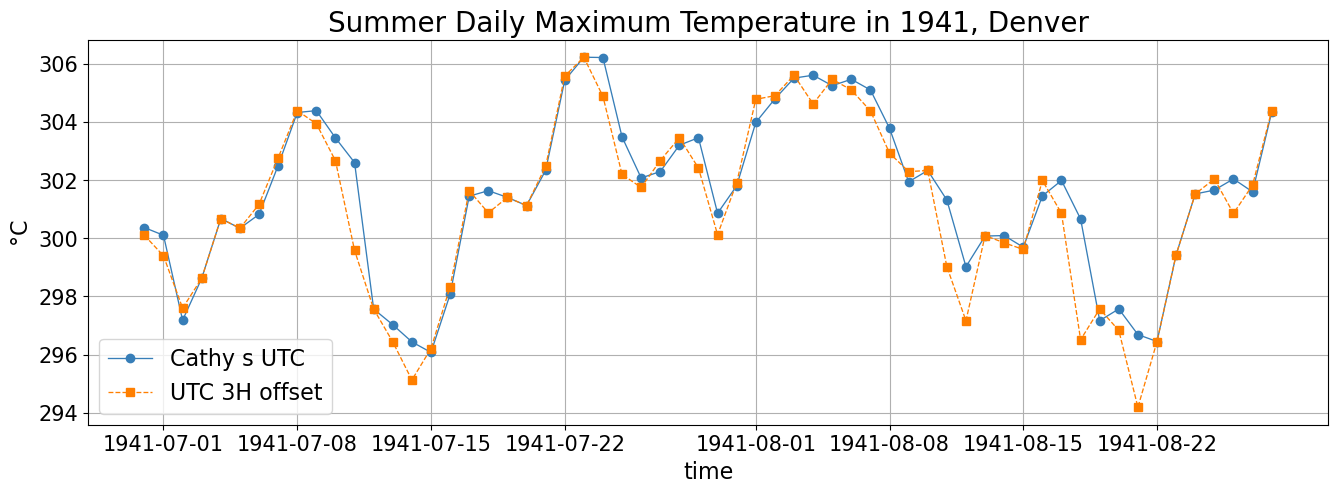

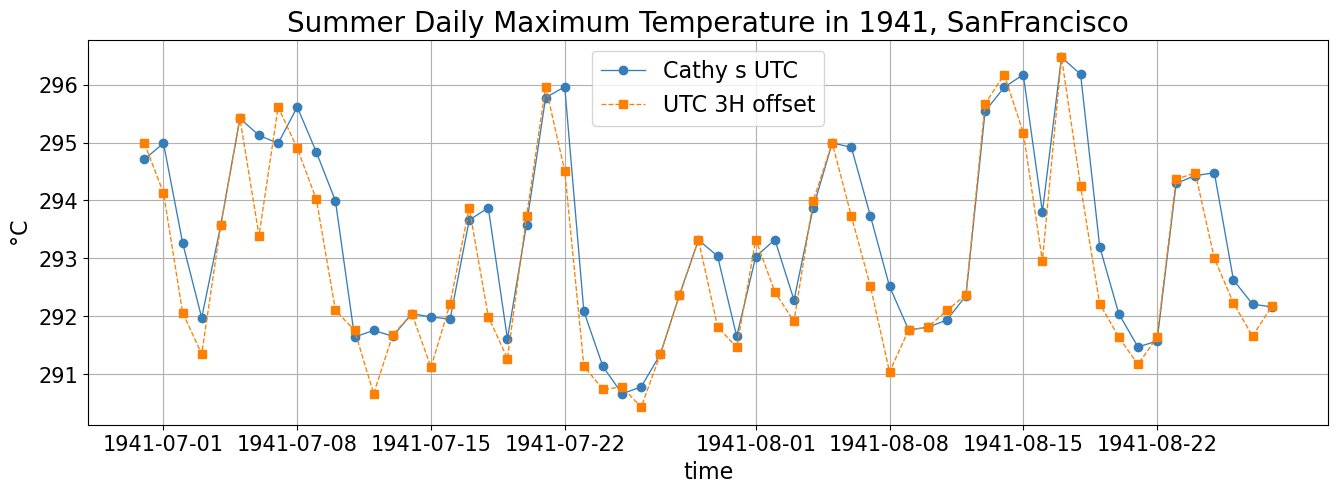

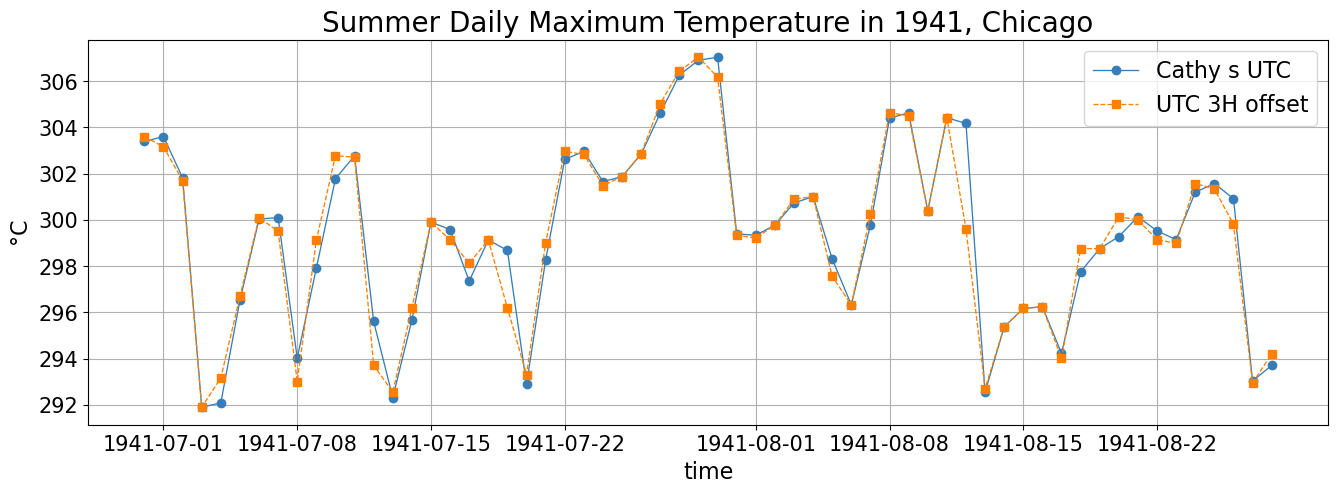

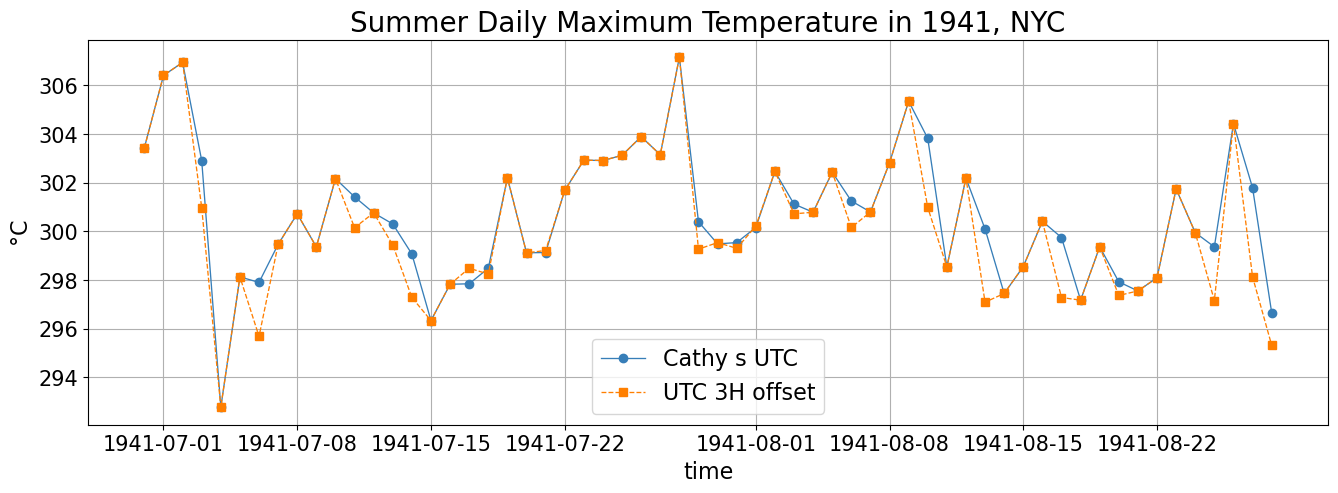

In [20]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'].isel(time=slice(180,240)),UTC[ip].isel(time=slice(180,240)),marker='o',color=CB_color[0],linewidth=0.95,label='Cathy s UTC')
  ax.plot(tmaxSLD['time'].isel(time=slice(180,240)),SLD[ip].isel(time=slice(180,240)),marker='s',color=CB_color[1],linewidth=0.95,linestyle='--',label='UTC 3H offset')
  ax.tick_params(labelsize=15)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Summer Daily Maximum Temperature in {tmaxUTC["time"].dt.strftime("%Y")[0].data}, {tip[ip]}',fontsize=20)
  plt.show()

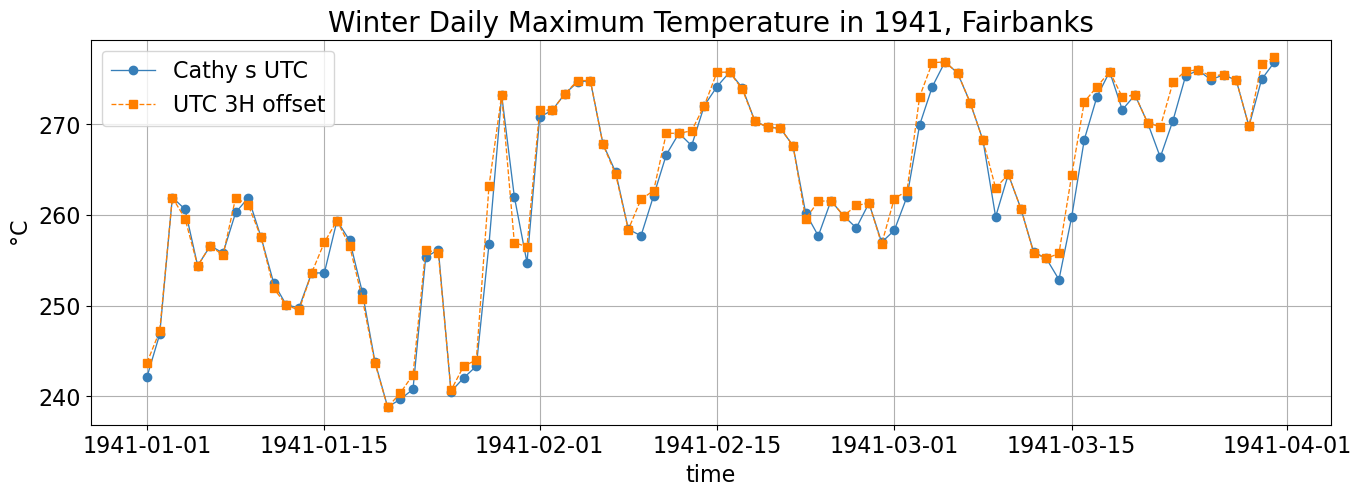

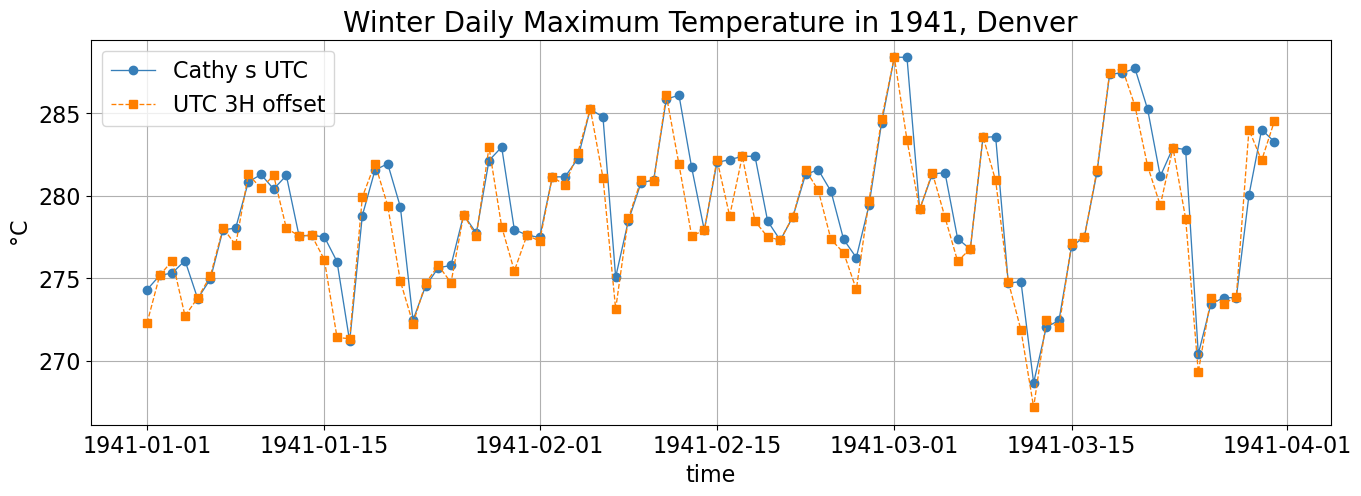

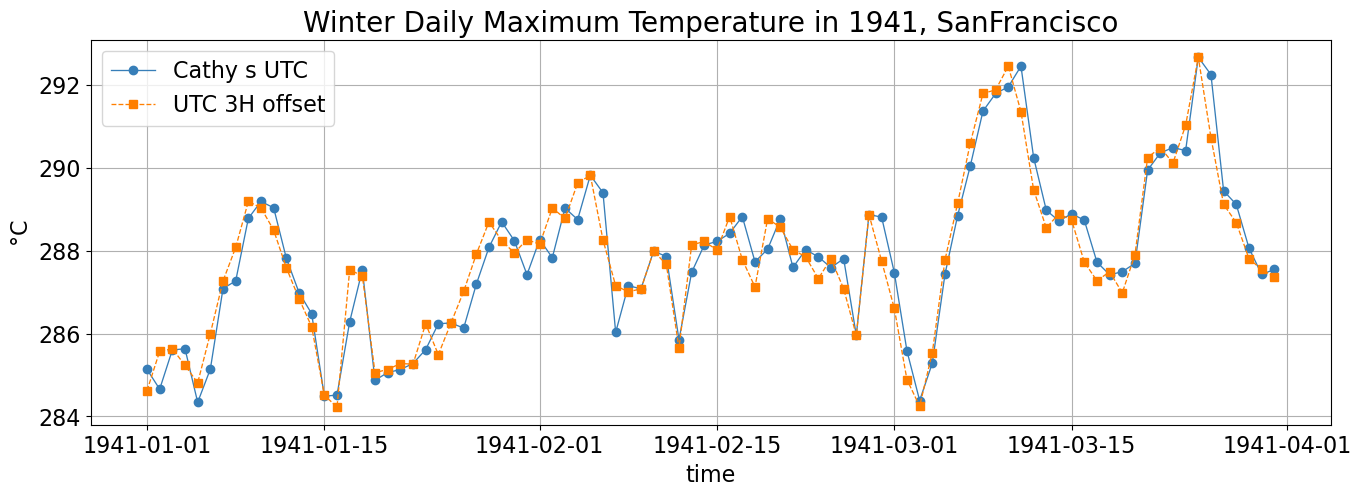

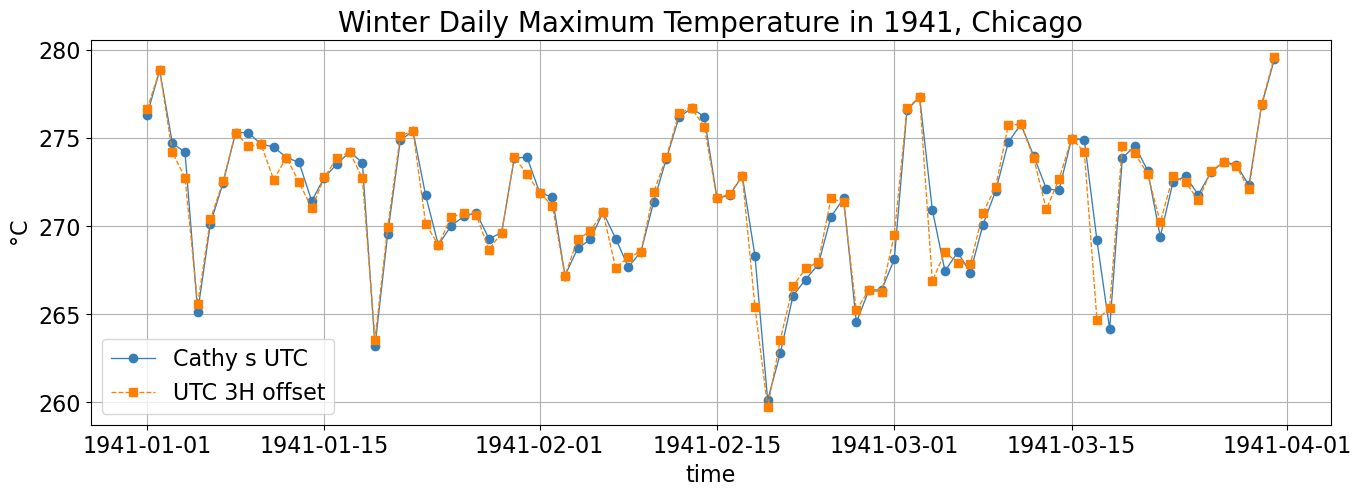

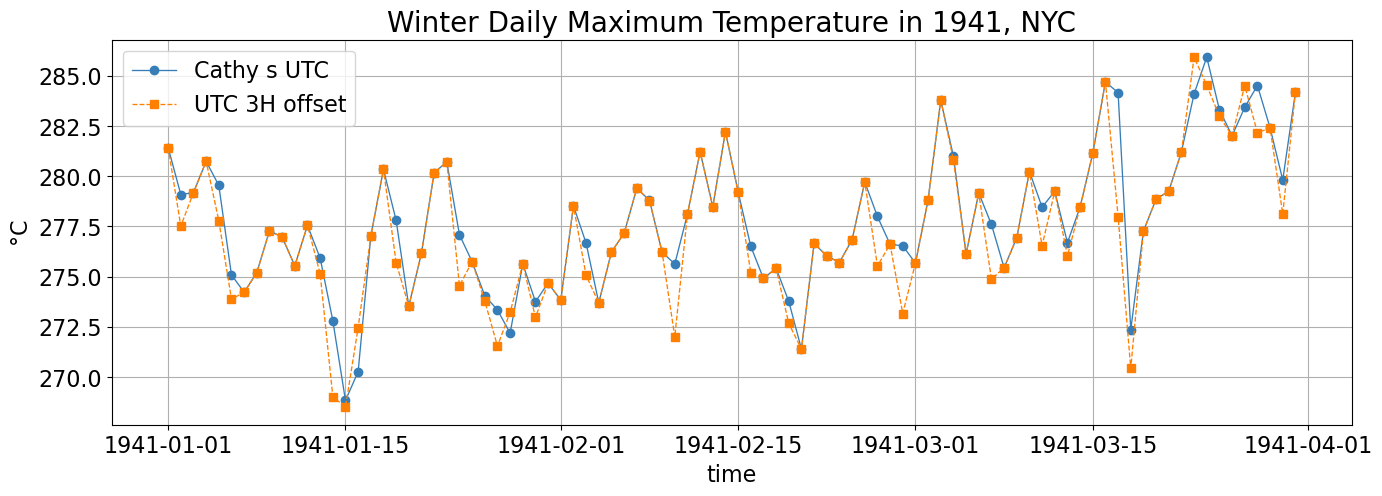

In [21]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'].isel(time=slice(0,90)),UTC[ip].isel(time=slice(0,90)),marker='o',color=CB_color[0],linewidth=0.95,label='Cathy s UTC')
  ax.plot(tmaxSLD['time'].isel(time=slice(0,90)),SLD[ip].isel(time=slice(0,90)),marker='s',color=CB_color[1],linewidth=0.95,linestyle='--',label='UTC 3H offset')
  ax.tick_params(labelsize=16)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Winter Daily Maximum Temperature in {tmaxUTC["time"].dt.strftime("%Y")[0].data}, {tip[ip]}',fontsize=20)
  plt.show()

# GMT 0 time

In [22]:
ds=xr.open_dataset("/Projects/era5/monolevel/tmax.2m.1960.nc")
ds['time'].data[0:24]

array(['1960-01-01T00:00:00.000000000', '1960-01-01T03:00:00.000000000',
       '1960-01-01T06:00:00.000000000', '1960-01-01T09:00:00.000000000',
       '1960-01-01T12:00:00.000000000', '1960-01-01T15:00:00.000000000',
       '1960-01-01T18:00:00.000000000', '1960-01-01T21:00:00.000000000',
       '1960-01-02T00:00:00.000000000', '1960-01-02T03:00:00.000000000',
       '1960-01-02T06:00:00.000000000', '1960-01-02T09:00:00.000000000',
       '1960-01-02T12:00:00.000000000', '1960-01-02T15:00:00.000000000',
       '1960-01-02T18:00:00.000000000', '1960-01-02T21:00:00.000000000',
       '1960-01-03T00:00:00.000000000', '1960-01-03T03:00:00.000000000',
       '1960-01-03T06:00:00.000000000', '1960-01-03T09:00:00.000000000',
       '1960-01-03T12:00:00.000000000', '1960-01-03T15:00:00.000000000',
       '1960-01-03T18:00:00.000000000', '1960-01-03T21:00:00.000000000'],
      dtype='datetime64[ns]')

# GMT + offset (-3,H) due to ERA5 timestamp convention

In [23]:
(ds['time'] + np.timedelta64(-3, 'h')).data[0:24]

array(['1959-12-31T21:00:00.000000000', '1960-01-01T00:00:00.000000000',
       '1960-01-01T03:00:00.000000000', '1960-01-01T06:00:00.000000000',
       '1960-01-01T09:00:00.000000000', '1960-01-01T12:00:00.000000000',
       '1960-01-01T15:00:00.000000000', '1960-01-01T18:00:00.000000000',
       '1960-01-01T21:00:00.000000000', '1960-01-02T00:00:00.000000000',
       '1960-01-02T03:00:00.000000000', '1960-01-02T06:00:00.000000000',
       '1960-01-02T09:00:00.000000000', '1960-01-02T12:00:00.000000000',
       '1960-01-02T15:00:00.000000000', '1960-01-02T18:00:00.000000000',
       '1960-01-02T21:00:00.000000000', '1960-01-03T00:00:00.000000000',
       '1960-01-03T03:00:00.000000000', '1960-01-03T06:00:00.000000000',
       '1960-01-03T09:00:00.000000000', '1960-01-03T12:00:00.000000000',
       '1960-01-03T15:00:00.000000000', '1960-01-03T18:00:00.000000000'],
      dtype='datetime64[ns]')